In [36]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from cs336_basics.model import TransformerLM, get_validation_loss

In [ ]:
o = torch.load("./train2-smol.step5000.pt", map_location=torch.device('cpu'))
training_loss = o['training_loss']
training_loss = training_loss[training_loss != 0.0]
lrs = o['lr']

In [37]:
# cp_nums = []
cp_nums = [3000, 4000, 5000]
cp_files = [f'train2-smol.step{i}.pt' for i in cp_nums]
with torch.device('mps:0'):
    cp_models = [torch.compile(TransformerLM.from_state_dict(torch.load(f, map_location='mps:0')['model'])) for f in cp_files]
validation_dataset = np.load('./tinystories-valid.npy', mmap_mode='r')
# print(validation_dataset.shape, validation_dataset[:100])

cp_validation_loss = []
for model in tqdm(cp_models, desc='checkpoint'):
    validation_loss = get_validation_loss(model, validation_dataset, batch_size=32, context_length=model.context_length, device='mps:0')
    cp_validation_loss.append(validation_loss)


checkpoint:   0%|          | 0/3 [00:00<?, ?it/s]

validation pass:   0%|          | 0/673 [00:00<?, ?it/s]

W0919 23:14:52.796000 15382 torch/_inductor/utils.py:1731] [0/0] Not enough SMs to use max_autotune_gemm mode


validation pass:   0%|          | 0/673 [00:00<?, ?it/s]

validation pass:   0%|          | 0/673 [00:00<?, ?it/s]

In [38]:
list(zip(cp_nums, cp_validation_loss))

[(3000, 2.4001623546506368),
 (4000, 2.2367757384913376),
 (5000, 2.1521348466434254)]

In [39]:
torch.save({
    'checkpoint_stepcount': cp_nums, 
    'checkpoint_validation_loss': cp_validation_loss,
    'lr': lrs.to(dtype=torch.float16),
    'training_loss': training_loss,
    'model_hyper': o['model']['hyper'],
}, 'train2-smol.metrics.pt')

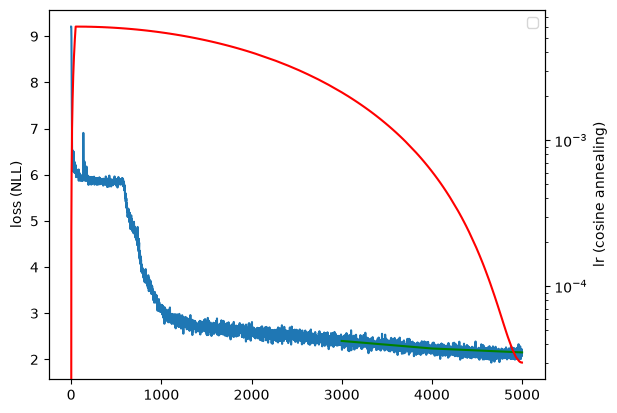

In [40]:
# https://matplotlib.org/stable/gallery/subplots_axes_and_figures/two_scales.html
fig, ax1 = plt.subplots()
ax1.set_ylabel('loss (NLL)')
line_trainloss, = ax1.plot(training_loss, label='training loss')
# validation loss
if cp_nums and cp_validation_loss:
  line_validloss, = ax1.plot(cp_nums, cp_validation_loss, label='validation loss', color='green')
# ax1.legend()

ax2 = ax1.twinx()
ax2.set_yscale('log')
ax2.set_ylabel('lr (cosine annealing)')
line_lr, = ax2.plot(lrs, label='learning rate', color='red')
# ax2.legend()

lines = filter(bool, [
  line_trainloss, 
  line_validloss or None, 
  line_lr
])
plt.legend(lines, [l.get_label() for l in lines])
plt.show()